 # WebScrapping and Analysis

In [198]:
from bs4 import BeautifulSoup
import seaborn as sns
import requests
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [199]:
url = 'https://worldpopulationreview.com/countries'
page = requests.get(url)
soup = BeautifulSoup(page.text,'html')
print("Response : ",page)

Response :  <Response [200]>


In [200]:
soup

<!DOCTYPE html>
<html lang="en"> <head><meta charset="utf-8"/><meta content="width=device-width, initial-scale=1" name="viewport"/><title>Total Population by Country 2026</title><meta content="Discover population, economy, health, and more with the most comprehensive global statistics at your fingertips." name="description"/><link href="/manifest.webmanifest" rel="manifest"/><link href="/favicon.ico" rel="icon" sizes="32x32"/><link href="/favicon.svg" rel="icon" type="image/svg+xml"/><link href="/apple-touch-icon.png" rel="apple-touch-icon"/><link href="/sitemap-index.xml" rel="sitemap"/><link href="https://worldpopulationreview.com/countries" rel="canonical"/><meta content="website" property="og:type"/><meta content="https://worldpopulationreview.com/countries" property="og:url"/><meta content="Total Population by Country 2026" property="og:title"/><meta content="World Population Review" property="og:site_name"/><meta content="Discover population, economy, health, and more with the mo

In [201]:
table = soup.find('table', class_ = 'wpr-table')
print(table.prettify())

<table class="wpr-table not-prose relative min-w-full border-collapse" data-astro-cid-srpfaapy="" id="273d3e2b-23cb-4c9f-b40d-00de461895b8">
 <thead class="table-head bg-wpr-table_header_bg relative z-40 px-0 py-0 text-xs tracking-wider uppercase" data-astro-cid-srpfaapy="">
  <tr data-astro-cid-srpfaapy="">
   <th class="datatable-th border-wpr-table_border bg-wpr-table_header_bg text-wpr-table_header sticky top-0 border-none px-3 py-2 text-left align-bottom leading-4 text-nowrap md:px-4 sticky left-0 z-50 font-bold pointer-events-none" data-astro-cid-srpfaapy="" data-field="flagCode" style="width: 60px">
    <div class="bg-wpr-table_header_bg relative flex flex-col items-stretch justify-start" data-astro-cid-srpfaapy="">
     <div class="flex cursor-pointer flex-row items-center select-none" data-astro-cid-srpfaapy="">
      <span class="sort-indicator ml-1" data-astro-cid-srpfaapy="">
      </span>
     </div>
    </div>
   </th>
   <th class="datatable-th border-wpr-table_border bg

In [202]:
tableHead = table.find_all('th')
headerList = [th.text.strip() for th in tableHead[1:]]
print(headerList)

['Country', '2026 Pop.', 'Area (kmÂ²)', 'Density', 'Annual Change', '% Global Pop', 'Rank']


In [203]:
df = pd.DataFrame(columns = headerList)

In [204]:
df

,Country,2026 Pop.,Area (kmÂ²),Density,Annual Change,% Global Pop,Rank


In [205]:
tableBody = table.find_all('tr')
for row in tableBody[1:]:
    tableData = row.find_all('td')
    rowData = [td.text.strip() for td in tableData[1:]]
    # print(rowData)
    length = len(df)
    df.loc[length] = rowData

df

,Country,2026 Pop.,Area (kmÂ²),Density,Annual Change,% Global Pop,Rank
0,India,"1,476,630,000",3.3M,497,0.87%,18.45%,1
1,China,"1,412,910,000",9.7M,150,-0.23%,17.65%,2
2,United States,"349,035,000",9.4M,38,0.51%,4.36%,3
3,Indonesia,"287,887,000",1.9M,153,0.76%,3.6%,4
4,Pakistan,"259,300,000",881.9K,336,1.6%,3.24%,5
...,...,...,...,...,...,...,...
230,Montserrat,"4,328",102,42,-0.71%,< 0.01%,231
231,Falkland Islands,"3,465",12.2K,0.28,-0.12%,< 0.01%,232
232,Tokelau,"2,691",12,269,3.18%,< 0.01%,233
233,Niue,"1,822",261,7.0,0.05%,< 0.01%,234


In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 235 entries, 0 to 234
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country        235 non-null    object
 1   2026 Pop.      235 non-null    object
 2   Area (kmÂ²)    235 non-null    object
 3   Density        235 non-null    object
 4   Annual Change  235 non-null    object
 5   % Global Pop   235 non-null    object
 6   Rank           235 non-null    object
dtypes: object(7)
memory usage: 14.7+ KB


In [207]:
df = df.rename(columns={'2026 Pop.': 'Population',
                        'Area (kmÂ²)' : 'Area (km²)',
                        '% Global Pop' : 'Global Pop %',
                        'Annual Change' : 'Annual Change %'
                       })

In [208]:
df['Population'] = df['Population'].str.replace(',', '', regex=False)
df['Density'] = df['Density'].str.replace(',', '', regex=False).astype(float)
df['Area (km²)'] = df['Area (km²)'].str.replace('[<> ]', '', regex=True)
df['Global Pop %'] = df['Global Pop %'].str.replace('[%><,]', '', regex=True).astype(float)
df['Annual Change %'] = df['Annual Change %'].str.replace('%', '', regex=True).astype(float)
df['Population'] = df['Population'].astype(int)
df['Rank'] = df['Rank'].astype(int)

In [209]:
def cleanArea(value):
    value = str(value).replace(',', '').replace('<', '').replace('>', '').strip()
    if 'M' in value:
        return float(value.replace('M', '')) * 1_000_000
    elif 'K' in value:
        return float(value.replace('K', '')) * 1_000
    else:
        return float(value)

df['Area (km²)'] = df['Area (km²)'].apply(cleanArea)

In [210]:
df

,Country,Population,Area (km²),Density,Annual Change %,Global Pop %,Rank
0,India,1476630000,3300000.0,497.00,0.87,18.45,1
1,China,1412910000,9700000.0,150.00,-0.23,17.65,2
2,United States,349035000,9400000.0,38.00,0.51,4.36,3
3,Indonesia,287887000,1900000.0,153.00,0.76,3.60,4
4,Pakistan,259300000,881900.0,336.00,1.60,3.24,5
...,...,...,...,...,...,...,...
230,Montserrat,4328,102.0,42.00,-0.71,0.01,231
231,Falkland Islands,3465,12200.0,0.28,-0.12,0.01,232
232,Tokelau,2691,12.0,269.00,3.18,0.01,233
233,Niue,1822,261.0,7.00,0.05,0.01,234


In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 235 entries, 0 to 234
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          235 non-null    object 
 1   Population       235 non-null    int64  
 2   Area (km²)       235 non-null    float64
 3   Density          235 non-null    float64
 4   Annual Change %  235 non-null    float64
 5   Global Pop %     235 non-null    float64
 6   Rank             235 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 14.7+ KB


In [212]:
totalPopulation = df['Population'].sum()
totalCountries = df['Country'].count()
print(f"Total World Population: {totalPopulation:,}")
print(f"Total Country: {totalCountries}")

Total World Population: 8,298,978,817
Total Country: 235


In [213]:
# Top 10 by Population
topTenPopCountries = df.nlargest(10, 'Population')[['Country', 'Population','Area (km²)']]
print("Top 10 Most Populous Countries:\n", topTenPopCountries.to_string(index=False))

# Top 10 by Land Area
topTenArea = df.nlargest(10, 'Area (km²)')[['Country', 'Area (km²)','Rank']]
print("\nTop 10 Largest Countries by Area:\n", topTenArea.to_string(index=False))

Top 10 Most Populous Countries:
       Country  Population  Area (km²)
        India  1476630000   3300000.0
        China  1412910000   9700000.0
United States   349035000   9400000.0
    Indonesia   287887000   1900000.0
     Pakistan   259300000    881900.0
      Nigeria   242432000    923800.0
       Brazil   213563000   8500000.0
   Bangladesh   177818000    147600.0
       Russia   143394000  17100000.0
     Ethiopia   138902000   1100000.0

Top 10 Largest Countries by Area:
       Country  Area (km²)  Rank
       Russia  17100000.0     9
       Canada  10000000.0    38
        China   9700000.0     2
United States   9400000.0     3
       Brazil   8500000.0     7
    Australia   7700000.0    55
        India   3300000.0     1
    Argentina   2800000.0    35
   Kazakhstan   2700000.0    65
      Algeria   2400000.0    32


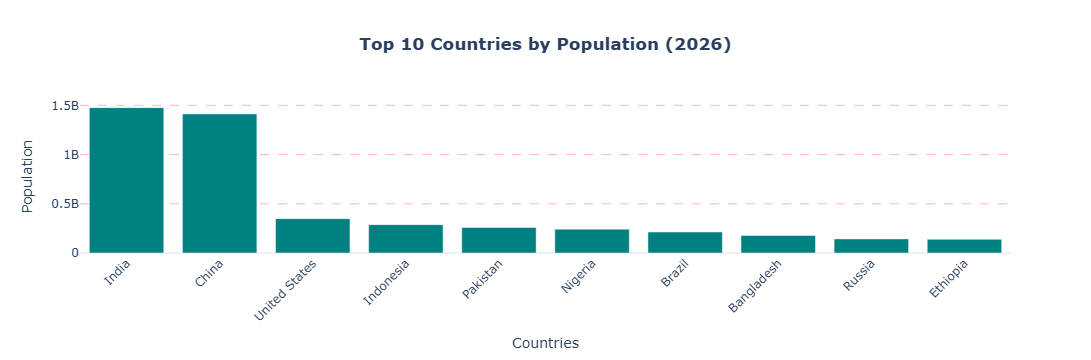

In [214]:
fig = px.bar(
    topTenPopCountries, 
    x='Country', 
    y='Population',
    title='<b>Top 10 Countries by Population (2026)</b>',
    labels={'Population': 'Population', 'Country': 'Countries'},
    color_discrete_sequence=['teal'] # Sets the bar color to teal
)

# 2. Match your Matplotlib styling (Rotation, Grid, Labels)
fig.update_layout(
    xaxis_tickangle=-45,        # Matches plt.xticks(rotation=45)
    yaxis_title="Population",    # Y-axis label
    template="plotly_white",     # Clean white background
    title_x=0.5,                 # Centers the title
    font=dict(size=12)           # Matches your fontsize=12
)

# 3. Optional: Customize the grid lines to match plt.grid(linestyle='--')
fig.update_yaxes(
    showgrid=True, 
    gridwidth=1, 
    gridcolor='LightPink', # or 'LightGray'
    griddash='dash'
)

fig.show()

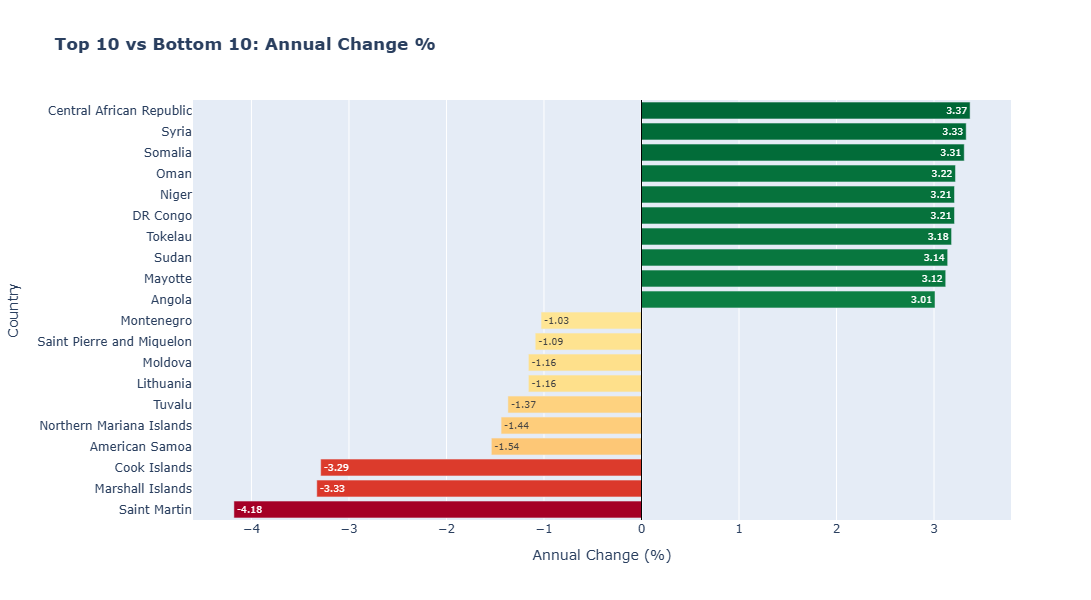

In [215]:
growthSorted = df.sort_values('Annual Change %', ascending=False)
extremeData = pd.concat([growthSorted.head(10), growthSorted.tail(10)])

# 2. Create the Bar Chart
fig = px.bar(
    extremeData,
    x='Annual Change %',
    y='Country',
    orientation='h',
    color='Annual Change %',          # Color bars based on the value
    color_continuous_scale='RdYlGn', # Matches your 'RdYlGn' palette
    title='<b>Top 10 vs Bottom 10: Annual Change %</b>', # <b> makes it bold
    text_auto='.2f'                  # Optional: shows the % value on the bars
)

# 3. Add the vertical line at 0
fig.add_vline(x=0, line_width=1, line_color="black")

# 4. Clean up the layout
fig.update_layout(
    yaxis={'categoryorder':'total ascending'}, # Ensures the bars stay sorted
    coloraxis_showscale=False,                 # Hides the color legend (optional)
    xaxis_title="Annual Change (%)",
    yaxis_title="Country",
    height=600
)

fig.show()

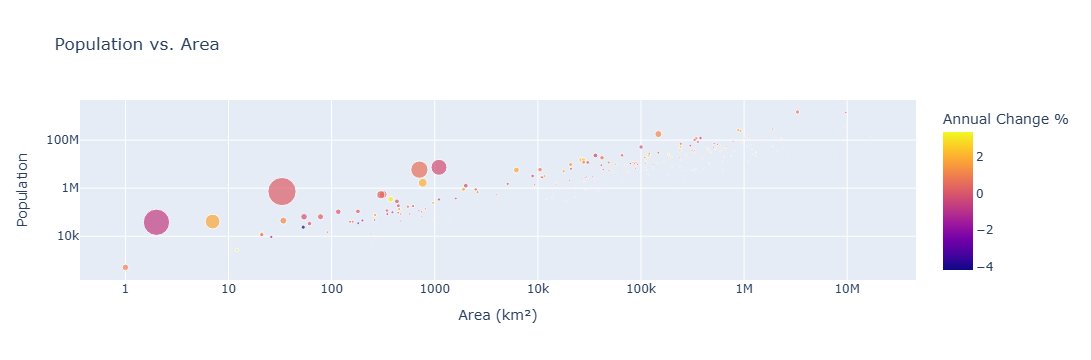

In [216]:
fig = px.scatter(
    df, 
    x="Area (km²)", 
    y="Population",
    size="Density", 
    color="Annual Change %",
    hover_name="Country",
    log_x=True, 
    log_y=True,
    title="Population vs. Area"
)

fig.show()